# Projects

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.in2p3.fr%2Fenergy4climate%2Fpublic%2Feducation%2Fmachine_learning_for_climate_and_energy/master?filepath=book%2Fnotebooks%2Fprojects.ipynb)

# Project Introduction: Meteorological Drivers of Wind Power Generation

---

## 1. Project Overview

The primary objective of this study is to analyze the relationship between large-scale atmospheric conditions and the energy production of onshore wind farms.

We aim to determine if historical meteorological data can be effectively mapped to wind energy efficiency. Mathematically, we seek a function $f$ that links the atmospheric state matrix ($X$) to the observed power output ($y$):

$$y \approx f(X)$$

The nature of this relationship—whether linear, simple, or highly complex—is the subject of this investigation.

---

## 2. The Target Variable ($y$)

We aim to predict the **Capacity Factor** (`capacityfactor_wind_onshore`).

> **Definition:** The ratio of the actual electrical energy output to the maximum possible electrical energy output over a given period.

* **Range:** $y \in [0, 1]$ (representing 0% to 100% efficiency).
* **Interpretation:** A value of 0.0 indicates no production (calm wind or maintenance), while 1.0 indicates turbines operating at full rated power.

---

## 3. The Input Data ($X$)

The predictor variables are derived from the **MERRA-2** (Modern-Era Retrospective analysis for Research and Applications) reanalysis dataset, spanning the period 2010-2019. These variables characterize the **aerodynamic** and **thermodynamic** state of the atmosphere.

### A. Wind Dynamics
Wind vectors are provided at two vertical levels to capture both surface speed and vertical wind shear.

| Variable Name | Level | Description |
| :--- | :--- | :--- |
| **`zonal_wind`** ($u$) | Surface | West-to-East wind component. |
| **`meridional_wind`** ($v$) | Surface | South-to-North wind component. |
| **`upper_zonal_wind`** | Upper | High-altitude West-to-East component. |
| **`upper_meridional_wind`**| Upper | High-altitude South-to-North component. |



### B. Thermodynamics & Synoptic Context
These variables account for air density variations ($P \propto \rho$) and the large-scale weather regime.

| Variable Name | Category | Role in Prediction |
| :--- | :--- | :--- |
| **`surface_density`** | Thermodynamics | Directly affects power output (Air Density $\rho$). |
| **`surface_temperature`** | Thermodynamics | Influences density and potential icing conditions. |
| **`surface_specific_humidity`**| Thermodynamics | Affects air mass properties and stability. |
| **`height_500`** | Synoptic | **Geopotential height at 500hPa**. Proxy for high/low pressure systems. |

## Reading the data

<Axes: xlabel='time'>

<Figure size 640x480 with 0 Axes>

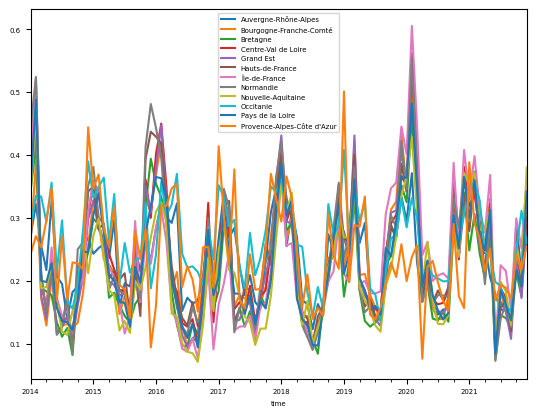

In [25]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import numpy as np

# Directories where you saved the data
data_dir_energy = Path('energy_france')
data_dir_climate = Path('climate_france')
                        
# Template filenames
filename_mask = 'mask_datagouv_french_regions_merra2_Nx_France.nc'
filename_climate = 'merra2_area_selection_output_{}_merra2_2010-2019.nc'
filename_energy = 'reseaux_energies_{}.csv'


# Read energy variable and plot time series
variable_name = 'capacityfactor_wind-onshore'
filename = filename_energy.format(variable_name)
filepath = Path(data_dir_energy, filename)
df_energy_wind = pd.read_csv(filepath, index_col=0, header=0, parse_dates=True)
plt.figure()
df_energy_wind.plot()



In [26]:
# Read a climate variable and plot its mean over time
filepath_mask = Path(data_dir_climate, filename_mask)
ds_mask = xr.load_dataset(filepath_mask)
da_mask = ds_mask['mask']

variable_name = 'zonal_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_zonal_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_zonal_wind = da_climate_zonal_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_zonal_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_zonal_wind.plot.line(x='time')

variable_name = 'upper_zonal_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_upper_zonal_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_upper_zonal_wind = da_climate_upper_zonal_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_upper_zonal_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_upper_zonal_wind.plot.line(x='time')

variable_name = 'meridional_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_meridional_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_meridional_wind = da_climate_meridional_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_meridional_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_meridional_wind.plot.line(x='time')

variable_name = 'upper_meridional_wind'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_upper_meridional_wind = xr.load_dataset(filepath)[variable_name]
da_climate_reg_upper_meridional_wind = da_climate_upper_meridional_wind.groupby(da_mask).mean().rename(mask='region')
da_climate_reg_upper_meridional_wind['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_reg_upper_meridional_wind.plot.line(x='time')


variable_name = 'height_500'
filename = filename_climate.format(variable_name)
filepath = Path(data_dir_climate, filename)
da_climate_height_500 = xr.load_dataset(filepath)[variable_name]
da_climate_height_500 = da_climate_height_500.groupby(da_mask).mean().rename(mask='region')
da_climate_height_500['region'] = ds_mask['region'].values
#plt.figure()
#da_climate_height_500.plot.line(x='time')


## Create the dataframe 

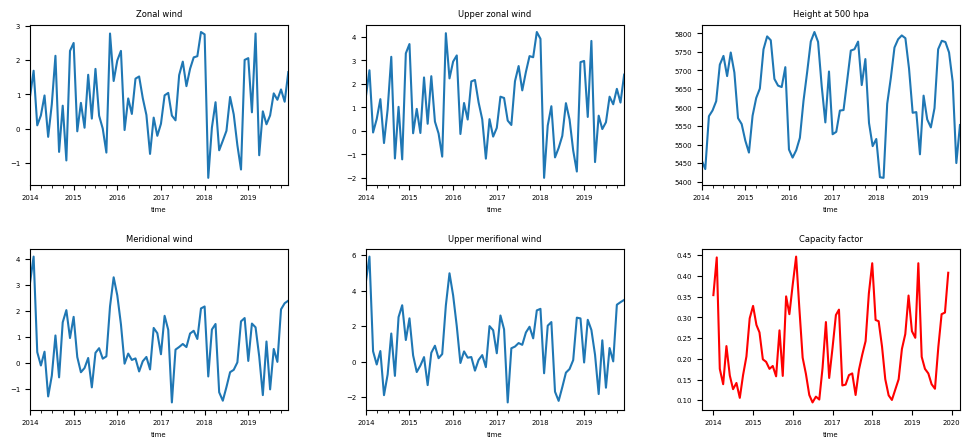

In [43]:
region_names = ds_mask['region'].values
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

variables = {
    'zonal_wind': da_climate_reg_zonal_wind,
    'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
    'meridional_wind': da_climate_reg_meridional_wind,
    'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
    'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
}


region_names = ds_mask['region'].values

# récupération de l'indice de la région Grand Est
idx_grand_est = np.where(region_names == 'Grand Est')[0][0]

df_grand_est = pd.DataFrame()

for var_name, da in variables.items():

    # on vérifie le nom de la dimension région
    region_dim = 'region' if 'region' in da.coords else 'mask'

    # extraction
    df_grand_est[var_name] = da.isel({region_dim: idx_grand_est}).to_pandas()

df_grand_est = df_grand_est.resample('MS').mean().loc['2014-01-01':'2019-12-31']

df_grand_est["capacityfactor_wind_onshore"] = df_energy_wind["Grand Est"].loc['2014-01-01':'2019-12-31']

plt.figure(figsize=(12,5))
plt.subplot(2,3,1)
df_grand_est['zonal_wind'].plot.line(x='time')
plt.title('Zonal wind')

plt.subplot(2,3,2)
df_grand_est['upper_zonal_wind'].plot.line(x='time',y='upper_zonal_wind')
plt.title('Upper zonal wind')

plt.subplot(2,3,4)
df_grand_est['meridional_wind'].plot.line(x='time')
plt.title('Meridional wind')

plt.subplot(2,3,5)
df_grand_est['upper_meridional_wind'].plot.line(x='time')
plt.title('Upper merifional wind')

plt.subplot(2,3,3)
df_grand_est['height_500'].plot.line(x='time')
plt.title('Height at 500 hpa')


plt.subplot(2,3,6)
plt.plot(df_grand_est.index, df_grand_est['capacityfactor_wind_onshore'], color = 'red')
plt.xlabel('time')
plt.title('Capacity factor')

plt.subplots_adjust(
    wspace=0.3,   # espace horizontal entre subplots
    hspace=0.4    # espace vertical entre subplots
)

## Try a simple linear regression 

R2 : 0.7887072742725008


Text(0.5, 1.0, 'Capacity factor')

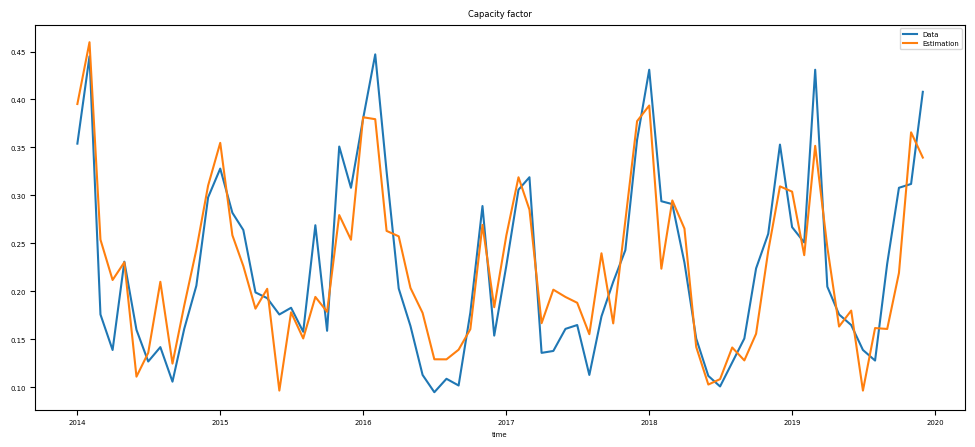

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


X_train = df_grand_est[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
y_train = df_grand_est['capacityfactor_wind_onshore'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Régression
reg = LinearRegression()
reg.fit(X_scaled, y_train)

print("R2 :", reg.score(X_scaled, y_train))
#print("Intercept :", reg.intercept_)
#print("Coefficients :", reg.coef_)

y_pred = reg.predict(X_scaled)


plt.figure(figsize=(12,5))
plt.plot(df_grand_est.index,y_train,label='Data')
plt.plot(df_grand_est.index,y_pred,label='Estimation')
plt.legend()
plt.xlabel('time')
plt.title('Capacity factor')

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


X_train = df_grand_est['height_500'].values[:,None]
y_train = df_grand_est['capacityfactor_wind_onshore'].values

reg = LinearRegression(fit_intercept=True)

reg.fit(X_train, y_train)

print("R2 :", reg.score(X_train, y_train))
print("Intercept :", reg.intercept_)
print("Coefficients :", reg.coef_)

R2 : 0.5473632977912206
Intercept : 3.7645106
Coefficients : [-0.00062809]


## Testing Physics-Informed Features

In this section, we want to **test a hypothesis**: can we improve our model's performance by explicitly calculating features based on wind physics?

We are not sure yet if this will provide a significant boost, but we aim to explore three specific transformations:

* **Speed & Direction:** Does the model learn better with explicit **Wind Speed** ($w$) and **Angle** ($\theta$) inputs rather than raw Cartesian vectors ($u, v$)?
* **The "Cube" Law ($v^3$):** Since power is theoretically proportional to the cube of the speed ($P \propto v^3$), we will test if pre-calculating this term helps linearize the problem for our simpler models.
* **Shear & Cycles:** We will investigate if adding **Vertical Wind Shear** (stability proxy) and **Cyclical Time Features** (preserving day/night continuity) brings meaningful context to the prediction.

We will compute these features and **compare the results** against our baseline to validate (or reject) their usefulness.

In [56]:
import numpy as np

# --- 1. FEATURE ENGINEERING ---

# A. Wind Speed (Magnitude): sqrt(u^2 + v^2)
df_grand_est['wind_speed'] = np.sqrt(df_grand_est['zonal_wind']**2 + df_grand_est['meridional_wind']**2)
df_grand_est['upper_wind_speed'] = np.sqrt(df_grand_est['upper_zonal_wind']**2 + df_grand_est['upper_meridional_wind']**2)

# B. Wind Angle (Direction): arctan2(v, u)
# Note: Keeping radians is fine for the model
df_grand_est['wind_angle'] = np.arctan2(df_grand_est['meridional_wind'], df_grand_est['zonal_wind'])
df_grand_est['upper_wind_angle'] = np.arctan2(df_grand_est['upper_meridional_wind'], df_grand_est['upper_zonal_wind'])

# C. Cube Law (Non-linearity)
# Power is theoretically proportional to v^3
df_grand_est['wind_speed_cubed'] = df_grand_est['wind_speed']**3

# D. Shear
# Difference between Upper and Surface speeds (Proxy for stability)
df_grand_est['shear_speed'] = df_grand_est['upper_wind_speed'] - df_grand_est['wind_speed']

# E. Cyclical Time (Seasonality)
# Encoding month (1-12) onto a circle so Dec (12) is close to Jan (1)
df_grand_est['month_sin'] = np.sin(2 * np.pi * df_grand_est.index.month / 12)
df_grand_est['month_cos'] = np.cos(2 * np.pi * df_grand_est.index.month / 12)

# Preview
print("Generated new features:")
display(df_grand_est[['wind_speed','wind_angle','upper_wind_angle', 'wind_speed_cubed', 'shear_speed', 'month_sin','month_cos','upper_wind_speed']].head())


Generated new features:


,wind_speed,wind_angle,upper_wind_angle,wind_speed_cubed,shear_speed,month_sin,month_cos,upper_wind_speed
time,,,,,,,,
2014-01-01,3.209754,1.276944,1.257797,33.068565,1.483180,0.500000,8.660254e-01,4.692934
2014-02-01,4.427172,1.178148,1.158928,86.771927,2.023317,0.866025,5.000000e-01,6.450490
2014-03-01,0.435942,1.344057,1.683781,0.082849,0.154782,1.000000,6.123234e-17,0.590724
2014-04-01,0.398390,-0.221634,-0.298133,0.063230,0.129369,0.866025,-5.000000e-01,0.527759
2014-05-01,1.066958,0.426800,0.419160,1.214623,0.413551,0.500000,-8.660254e-01,1.480509


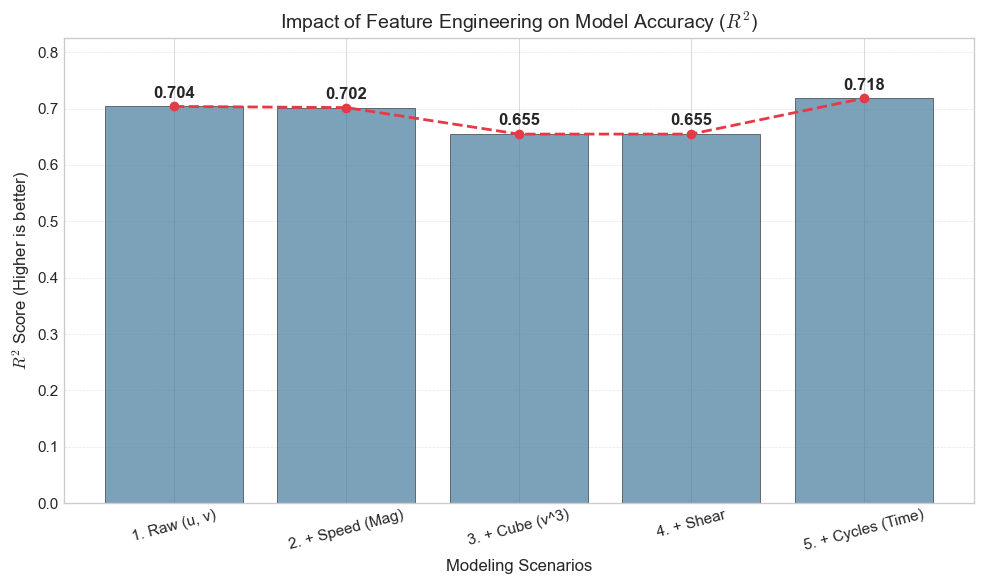

In [69]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# --- CONFIGURATION DES SCÉNARIOS ---
# On définit étape par étape ce qu'on rajoute
scenarios = [
    ("1. Raw (u, v)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500']),
     
    ("2. + Speed (Mag)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed']),
      
    ("3. + Cube (v^3)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed']),
      
    ("4. + Shear", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed']),
      
    ("5. + Cycles (Time)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed', 'month_sin', 'month_cos'])
]

# --- BOUCLE D'ENTRAÎNEMENT ---
scores = []
names = []

# Cible fixe
y = df_grand_est['capacityfactor_wind_onshore'].values

for name, features in scenarios:
    # 1. Préparation X
    X = df_grand_est[features].values
    
    # 2. Scaling
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)

    # 3. Fit
    reg = LinearRegression()
    reg.fit(X_scaled, y)
    
    # 4. Score
    r2 = cross_val_score(reg, X_scaled, y, cv=5, scoring='r2').mean()
    scores.append(r2)
    names.append(name)

# --- VISUALISATION ---
plt.figure(figsize=(10, 6))

# Tracer les barres
bars = plt.bar(names, scores, color='#457b9d', edgecolor='black', alpha=0.7)

# Tracer une ligne pour voir la tendance
plt.plot(names, scores, color='#e63946', marker='o', linewidth=2, linestyle='--')

# Ajouter les valeurs exactes sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", ha='center', va='bottom', fontweight='bold')

plt.title("Impact of Feature Engineering on Model Accuracy ($R^2$)", fontsize=14)
plt.ylabel("$R^2$ Score (Higher is better)", fontsize=12)
plt.xlabel("Modeling Scenarios", fontsize=12)
plt.ylim(0, max(scores) * 1.15) # Un peu d'espace en haut
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=15) # Pencher le texte pour qu'il soit lisible
plt.tight_layout()
plt.show()

Try if redundancy is a problem 

Strategy                       | CV R² Score
---------------------------------------------
1. Old (Raw Data + z500)       | 0.70389
2. New (Physics + z500)        | 0.59940
3. All-in (Raw + Physics)      | 0.63041


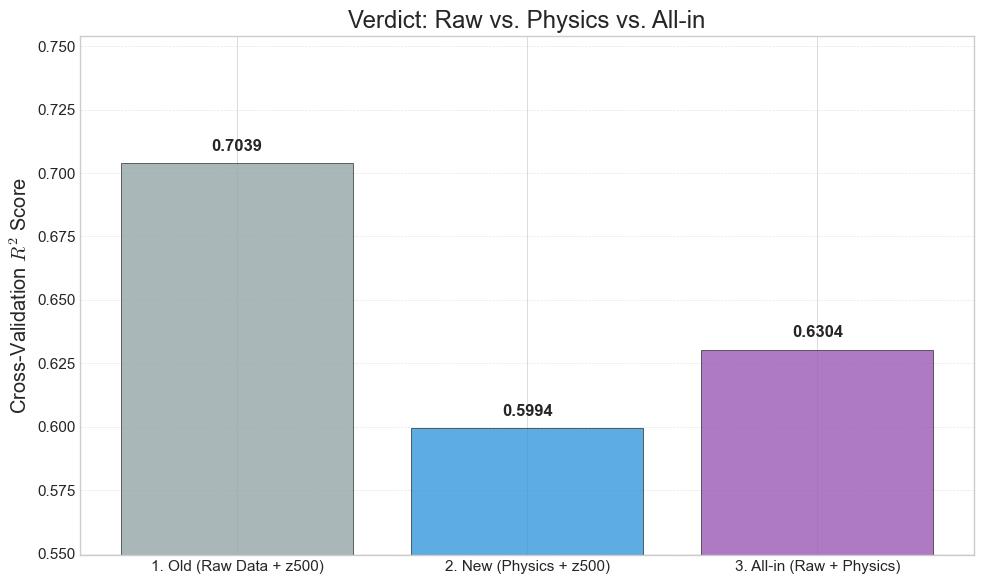

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# --- 1. DÉFINITION DU TRIPLE DUEL ---
strategies = [
    # A. données brut 
    ("1. Old (Raw Data + z500)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 
      'height_500']),

    # B. nouvelle features 
    ("2. New (Physics + z500)", 
     ['wind_speed_cubed', 'shear_speed', 'wind_angle', 'upper_wind_angle', 
      'month_sin', 'month_cos', 
      'height_500']),

    # C. tout 
    ("3. All-in (Raw + Physics)", 
     ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', # Raw
      'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed',           # Magnitude/Physique
      'wind_angle', 'upper_wind_angle',                                              # Angles
      'month_sin', 'month_cos',                                                      # Temps
      'height_500'])                                                                 # Contexte
]

# --- 2. LE MATCH (Cross-Validation) ---
scores = []
names = []
# On s'assure que y est bien défini
y = df_grand_est['capacityfactor_wind_onshore'].values

print(f"{'Strategy':<30} | {'CV R² Score'}")
print("-" * 45)

for name, features in strategies:
    # Sélection des colonnes
    X = df_grand_est[features].values
    
    # Scaling 
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    
    # Modèle
    reg = LinearRegression()
    
    # Evaluation (Moyenne de 5 tests)
    cv_scores = cross_val_score(reg, X_scaled, y, cv=5, scoring='r2')
    mean_score = cv_scores.mean()
    
    scores.append(mean_score)
    names.append(name)
    
    print(f"{name:<30} | {mean_score:.5f}")


plt.figure(figsize=(10, 6))

# Couleurs : Gris (Base), Bleu (Physique), Violet (Tout)
colors = ['#95a5a6', '#3498db', '#9b59b6']
bars = plt.bar(names, scores, color=colors, edgecolor='black', alpha=0.8)

# Zoom
plt.ylim(min(scores) - 0.05, max(scores) + 0.05)
plt.ylabel("Cross-Validation $R^2$ Score")
plt.title("Verdict: Raw vs. Physics vs. All-in")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Affichage des valeurs exactes sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

##  Regularization: Lasso & Ridge

With the addition of our physics-informed features (like $v^3$, shear, etc.) alongside the raw data, we have introduced **redundancy** and **collinearity** (high correlation between variables). Standard Linear Regression can struggle in this context and may overfit.

In this section, we will test two regularization techniques to see if constraining the model yields better results:

* Ridge Regression
* Lasso Regression

Dataset                             | Best Ridge | Best Lasso
-----------------------------------------------------------------
1. Raw Data                         | 0.7105     | 0.7032
2. All-in (Redundant)               | 0.7118     | 0.6917
3. Raw + Cycles                     | 0.7251     | 0.7167


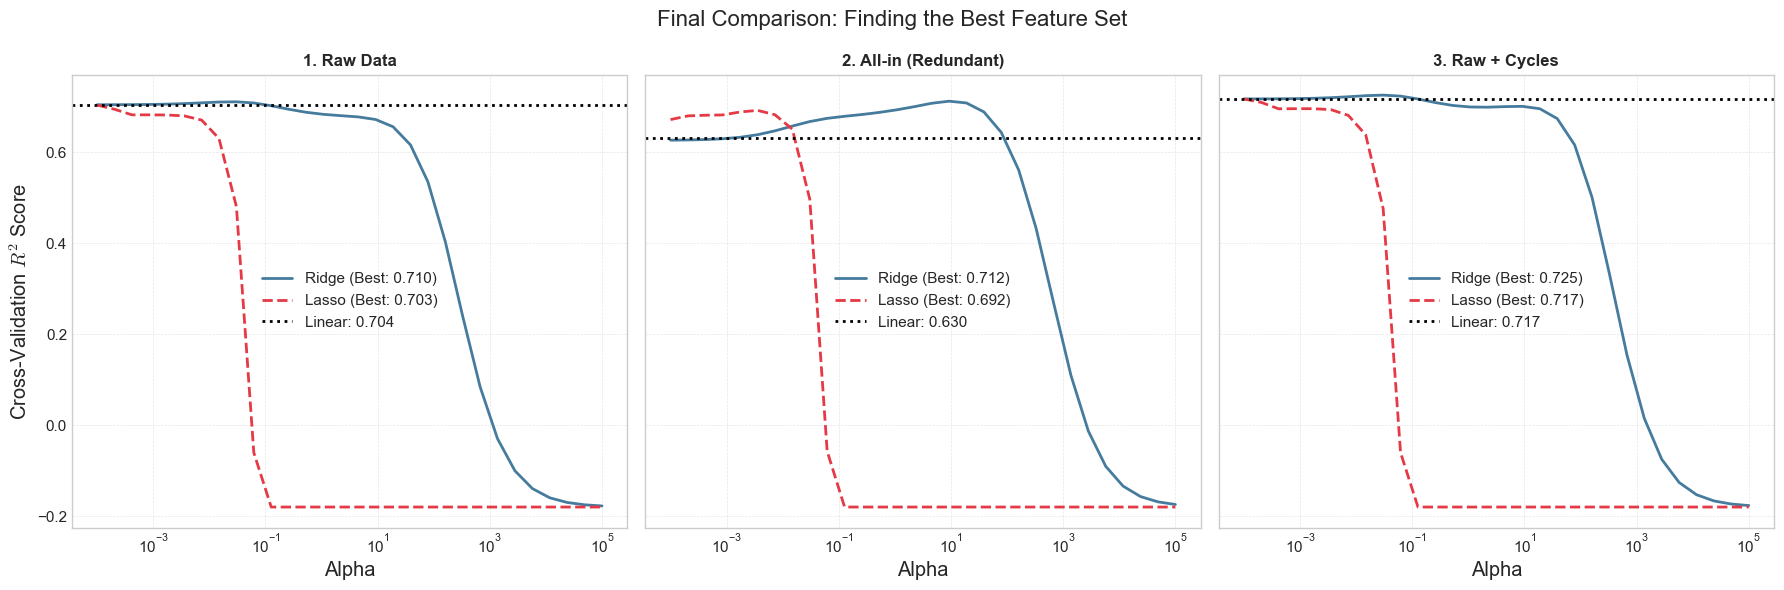

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# --- 1. CONFIGURATION DES 3 DATASETS ---

# A
features_raw = ['zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500']

# B.
features_all = [
    'zonal_wind', 'meridional_wind', 'upper_zonal_wind', 'upper_meridional_wind', 'height_500', 
    'wind_speed', 'upper_wind_speed', 'wind_speed_cubed', 'shear_speed', 
    'wind_angle', 'upper_wind_angle', 'month_sin', 'month_cos'
]

# C
features_raw_cycles = features_raw + ['month_sin', 'month_cos']

datasets = {
    "1. Raw Data": features_raw,
    "2. All-in (Redundant)": features_all,
    "3. Raw + Cycles": features_raw_cycles
}

# Paramètres
alphas = np.logspace(-4, 5, 30)
y = df_grand_est['capacityfactor_wind_onshore'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

print(f"{'Dataset':<35} | {'Best Ridge':<10} | {'Best Lasso'}")
print("-" * 65)

for i, (name, cols) in enumerate(datasets.items()):
    ax = axes[i]
    
    # A. Préparation
    X = df_grand_est[cols].values
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
    
    # B. Baseline (Linear)
    lin = LinearRegression()
    baseline = np.mean(cross_val_score(lin, X_scaled, y, cv=5, scoring='r2'))
    
    # C. Alphas Loop
    scores_ridge = []
    scores_lasso = []
    
    for a in alphas:
        r = Ridge(alpha=a)
        scores_ridge.append(np.mean(cross_val_score(r, X_scaled, y, cv=5, scoring='r2')))
        
        l = Lasso(alpha=a, max_iter=10000)
        scores_lasso.append(np.mean(cross_val_score(l, X_scaled, y, cv=5, scoring='r2')))
    
    # D. Meilleurs Scores pour affichage
    best_ridge = max(scores_ridge)
    best_lasso = max(scores_lasso)
    
    # E. Plotting
    ax.semilogx(alphas, scores_ridge, label=f'Ridge (Best: {best_ridge:.3f})', color='#457b9d', linewidth=2)
    ax.semilogx(alphas, scores_lasso, label=f'Lasso (Best: {best_lasso:.3f})', color='#e63946', linewidth=2, linestyle='--')
    ax.axhline(baseline, color='black', linestyle=':', label=f'Linear: {baseline:.3f}')
    
    # Esthétique
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Alpha')
    if i == 0: ax.set_ylabel('Cross-Validation $R^2$ Score')
    ax.grid(True, which="both", linestyle='--', alpha=0.5)
    ax.legend()
    
    print(f"{name:<35} | {best_ridge:.4f}     | {best_lasso:.4f}")

plt.suptitle("Final Comparison: Finding the Best Feature Set", fontsize=16)
plt.tight_layout()
plt.show()

### Simplicity and Context Prevail

After testing multiple feature engineering strategies and regularization techniques, we have arrived at an interesting and somewhat counter-intuitive conclusion regarding the modeling of wind power generation.

#### 1. The Winning Strategy: Raw Data + Time Cycles
Contrary to our initial hypothesis, complex physics-informed feature engineering (calculating $v^3$, shear, or explicit angles) did not yield the best performance.

The most accurate and robust model was achieved using the **simplest feature set**:
* **Raw Cartesian Vectors** ($u, v$): These handle wind direction continuously, avoiding the mathematical discontinuities introduced by calculating angles in radians.
* **Time Cycles** (`month_sin`, `month_cos`): Adding seasonality was the critical missing piece. It provides the model with implicit context regarding air density and atmospheric stability (e.g., winter vs. summer conditions).


## Generalize the processus by region

Testing the model by region. 

Testing one glogal model and see the difference by regions

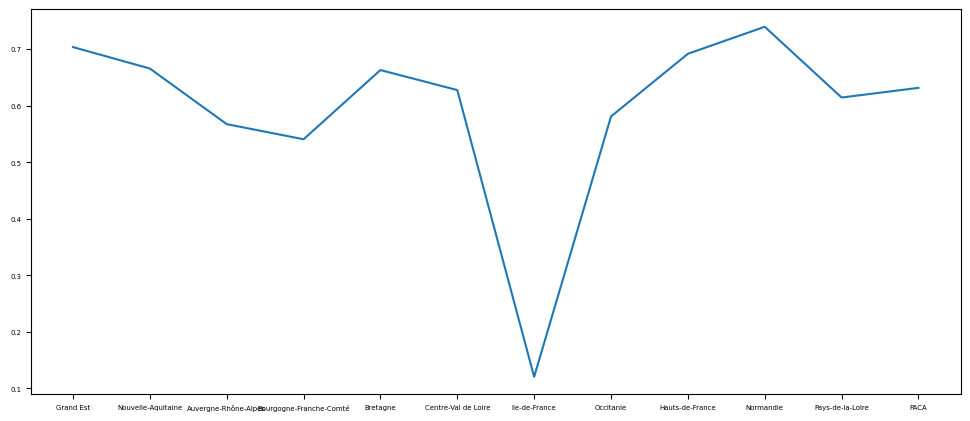

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

region_names = ds_mask['region'].values
r2_region = []
df_global = pd.DataFrame()   

for region_name in region_names :
    idx_region = np.where(region_names == region_name)[0][0]

    variables = {
        'zonal_wind': da_climate_reg_zonal_wind,
        'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
        'meridional_wind': da_climate_reg_meridional_wind,
        'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
        'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
    }

    df_region = pd.DataFrame()

    for var_name, da in variables.items():
        region_dim = 'region' if 'region' in da.coords else 'mask'
        df_region[var_name] = da.isel({region_dim: idx_region}).to_pandas()

    df_region = df_region.resample('MS').mean().loc['2014-01-01':'2019-12-31']

    if region_name == 'Ile-de-France' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Île-de-France'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'Pays-de-la-Loire' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Pays de la Loire'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'PACA' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Provence-Alpes-Côte d\'Azur'].loc['2014-01-01':'2019-12-31']
    else:
        df_region["capacityfactor_wind_onshore"] = df_energy_wind[region_name].loc['2014-01-01':'2019-12-31']

    df_global = pd.concat([df_global, df_region], axis=0)

    X_train = df_region[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
    y_train = df_region['capacityfactor_wind_onshore'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Régression
    reg = LinearRegression()
    reg.fit(X_scaled, y_train)
    
    cv_scores = cross_val_score(reg, X_scaled, y_train, cv=5, scoring='r2')
    mean_score = cv_scores.mean()
    r2_region.append(mean_score)

plt.figure(figsize=(12,5))
plt.rcParams['font.size'] = 5
plt.plot(region_names,r2_region)


0.5483336147981523


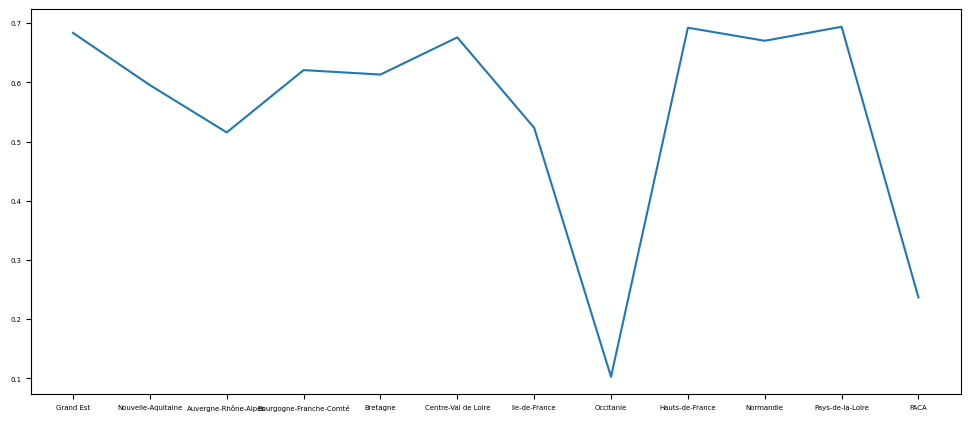

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_train = df_global[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
y_train = df_global['capacityfactor_wind_onshore'].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

reg = LinearRegression()
reg.fit(X_scaled, y_train)

print(reg.score(X_scaled, y_train))

r2_region_test = []

for region_name in region_names :
    idx_region = np.where(region_names == region_name)[0][0]

    variables = {
        'zonal_wind': da_climate_reg_zonal_wind,
        'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
        'meridional_wind': da_climate_reg_meridional_wind,
        'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
        'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
    }

    df_region = pd.DataFrame()

    for var_name, da in variables.items():
        region_dim = 'region' if 'region' in da.coords else 'mask'
        df_region[var_name] = da.isel({region_dim: idx_region}).to_pandas()

    df_region = df_region.resample('MS').mean().loc['2014-01-01':'2019-12-31']

    if region_name == 'Ile-de-France' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Île-de-France'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'Pays-de-la-Loire' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Pays de la Loire'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'PACA' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Provence-Alpes-Côte d\'Azur'].loc['2014-01-01':'2019-12-31']
    else:
        df_region["capacityfactor_wind_onshore"] = df_energy_wind[region_name].loc['2014-01-01':'2019-12-31']

    df_global = pd.concat([df_global, df_region], axis=0)

    X_test = df_region[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
    y_test = df_region['capacityfactor_wind_onshore'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_test)
    
    r2_region_test.append(reg.score(X_scaled, y_test))

plt.figure(figsize=(12,5))
plt.rcParams['font.size'] = 5
plt.plot(region_names,r2_region_test)

It's cleary better to estimate the capacity factor region by region

## Estimate with an anomaly

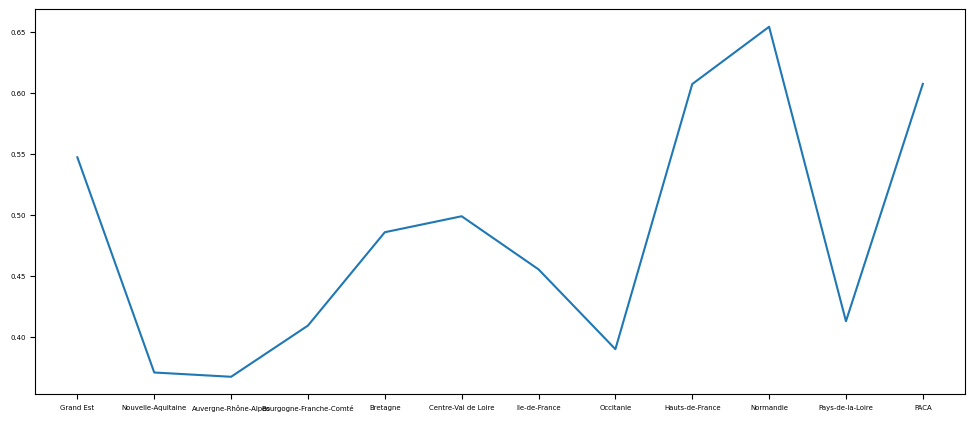

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

region_names = ds_mask['region'].values
r2_region = []
df_global = pd.DataFrame()   

for region_name in region_names :
    idx_region = np.where(region_names == region_name)[0][0]

    variables = {
        'zonal_wind': da_climate_reg_zonal_wind,
        'upper_zonal_wind': da_climate_reg_upper_zonal_wind,
        'meridional_wind': da_climate_reg_meridional_wind,
        'upper_meridional_wind': da_climate_reg_upper_meridional_wind,
        'height_500': da_climate_height_500,  # Corriger si mauvaise variable !
    }

    df_region = pd.DataFrame()

    for var_name, da in variables.items():
        region_dim = 'region' if 'region' in da.coords else 'mask'
        df_region[var_name] = da.isel({region_dim: idx_region}).to_pandas()

    df_region = df_region.resample('MS').mean().loc['2014-01-01':'2019-12-31']

    if region_name == 'Ile-de-France' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Île-de-France'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'Pays-de-la-Loire' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Pays de la Loire'].loc['2014-01-01':'2019-12-31']
    elif region_name == 'PACA' :
        df_region["capacityfactor_wind_onshore"] = df_energy_wind['Provence-Alpes-Côte d\'Azur'].loc['2014-01-01':'2019-12-31']
    else:
        df_region["capacityfactor_wind_onshore"] = df_energy_wind[region_name].loc['2014-01-01':'2019-12-31']

    df_region_mean = df_region.groupby(df_region.index.month).transform("mean")
    df_region_anomaly = df_region - df_region_mean
    
    X_train = df_region_anomaly[['zonal_wind','upper_zonal_wind','meridional_wind','upper_meridional_wind','height_500']].values
    y_train = df_region_anomaly['capacityfactor_wind_onshore'].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Régression
    reg = LinearRegression()
    reg.fit(X_scaled, y_train)

    r2_region.append(reg.score(X_scaled, y_train))

plt.figure(figsize=(12,5))
plt.rcParams['font.size'] = 5
plt.plot(region_names,r2_region)
